In [166]:
import numpy as np
import matplotlib.pyplot as plt
from QPGC import QPGenericConstraints

In [167]:
### Main functions ###

def create_dataset(m1, s1, m2, s2, n_samples=100, seed=None):
    """
    Create a binary classification dataset with two classes sampled from 
    multivariate normal distributions.
    
    Parameters
    ----------
    m1 : array-like
        Mean vector for class 1
    s1 : array-like
        Covariance matrix for class 1
    m2 : array-like
        Mean vector for class 2
    s2 : array-like
        Covariance matrix for class 2
    n_samples : int, optional
        Number of samples per class (default: 100)
    seed : int, optional
        Random seed for reproducibility (default: None)
    
    Returns
    -------
    X : ndarray of shape (2*n_samples, 2)
        Feature matrix with all data points
    y : ndarray of shape (2*n_samples,)
        Labels: +1 for class 1, -1 for class 2
    """
    if seed is not None:
        np.random.seed(seed)
    X1 = np.random.multivariate_normal(m1, s1, n_samples)
    y1 = np.ones(n_samples)
    X2 = np.random.multivariate_normal(m2, s2, n_samples)
    y2 = -np.ones(n_samples)
    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y

def SVM_hyperplane(X, y, K=1.0):
    """
    Train an SVM using QPGenericConstraints with regularization parameter K.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    K : float
        Regularization parameter (C in soft-margin SVM).
    
    Returns
    -------
    w : ndarray
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    alphas : ndarray
        Lagrange multipliers.
    """
    n = X.shape[0]
    p = 1
    m = 2 * n
    # Matrices for QP
    A = y.reshape(n, p)
    b_vec = np.zeros(p)
    C = np.concatenate((np.eye(n), -np.eye(n)), axis=1)
    d = np.concatenate((np.zeros(n), -K * np.ones(n)))
    Y = np.diag(y)
    G = Y @ X @ X.T @ Y
    g = -np.ones(n)
    # Solve QP
    alphas = QPGenericConstraints(G, g, A, C, b_vec, d)
    # Compute w and b
    w = (alphas * y) @ X
    sv = (alphas > 1e-5)
    b = np.mean(y[sv] - X[sv] @ w)
    return w, b, alphas


In [168]:
### Plotting functions ###

def plot_dataset(X, y, ax=None, title="Classification Dataset"):
    """
    Plot the dataset with different colors and shapes for each class.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Feature matrix
    y : ndarray of shape (n_samples,)
        Labels: +1 for class 1, -1 for class 2
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (default: creates new figure)
    title : str, optional
        Title for the plot (default: "Classification Dataset")
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    mask1 = y == 1
    ax.scatter(X[mask1, 0], X[mask1, 1], c='blue', marker='o', s=50, alpha=0.7, label='Class +1', edgecolors='darkblue')
    mask2 = y == -1
    ax.scatter(X[mask2, 0], X[mask2, 1], c='red', marker='s', s=50, alpha=0.7, label='Class -1', edgecolors='darkred')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    return ax

def plot_svm_with_margin(X, y, w, b, ax=None, title="SVM with Margin"):
    """
    Plot a 2D dataset together with the SVM decision boundary and margin lines.

    The plot is automatically centered on the data points, and the decision
    boundary along with its margins is drawn to span the full visible plot
    area for consistent scaling.

    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Input feature matrix containing 2D points.
    y : ndarray of shape (n_samples,)
        Class labels for each sample, expected to be +1 or -1.
    w : ndarray of shape (2,)
        Weight vector defining the SVM separating hyperplane.
    b : float
        Bias (intercept) term of the separating hyperplane.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axes to plot on. If None, a new figure and axes
        are created.
    title : str, optional
        Title displayed at the top of the plot.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The matplotlib axes object containing the plot.
    """
     
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    plot_dataset(X, y, ax=ax)

    # ---- Compute data-based limits with padding ----
    pad = 0.15
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    x_min -= pad * x_range
    x_max += pad * x_range
    y_min -= pad * y_range
    y_max += pad * y_range

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # ---- Plot hyperplane and margins across full axes ----
    if abs(w[1]) > 1e-8:
        xx = np.array([x_min, x_max])

        # Decision boundary
        yy = (-w[0] * xx - b) / w[1]
        ax.plot(xx, yy, 'k-', linewidth=2, label='SVM hyperplane')

        # Margins
        yy_p = (-w[0] * xx - b + 1) / w[1]
        yy_m = (-w[0] * xx - b - 1) / w[1]

        ax.plot(xx, yy_p, 'b--', linewidth=2, label='Margin +1')
        ax.plot(xx, yy_m, 'r-.', linewidth=2, label='Margin -1')

    # ---- Improve visual scaling ----
    ax.set_aspect('equal', adjustable='box')  # prevents distortion
    ax.margins(0.05)                          # small internal padding
    ax.legend()
    ax.set_title(title)

    return ax




## Dataset Parameters

Define the mean and covariance matrices for both classes.

In [169]:
# Class 1 parameters
m1 = [0., 0.]
s1 = [[1, -0.9], [-0.9, 1]]

# Class 2 parameters - Separable dataset
m2_separable = [3., 6.]
s2_separable = [[1, 0], [0, 1]]

# Class 2 parameters - Non-separable dataset 
m2_non_separable = [1., 2.]
s2_non_separable = [[1, 0], [0, 1]]

## Create and Visualize the Dataset

Separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


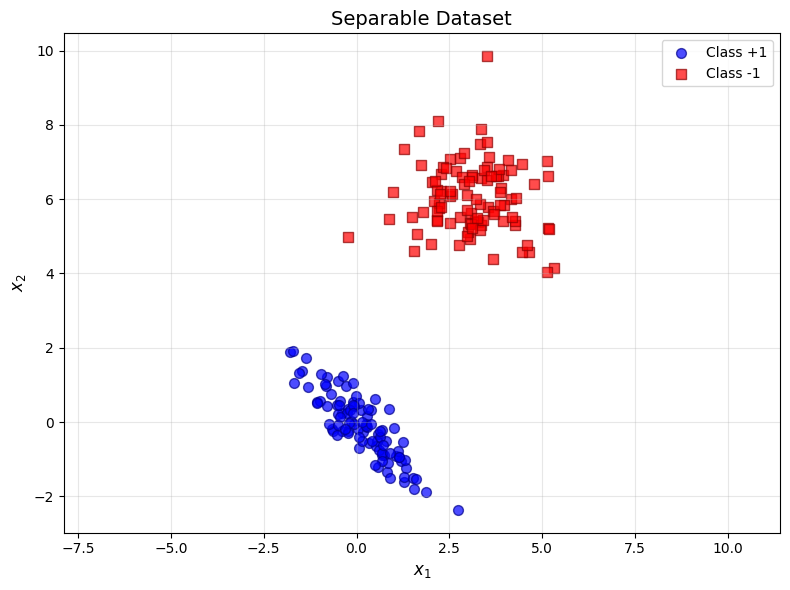

Non separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


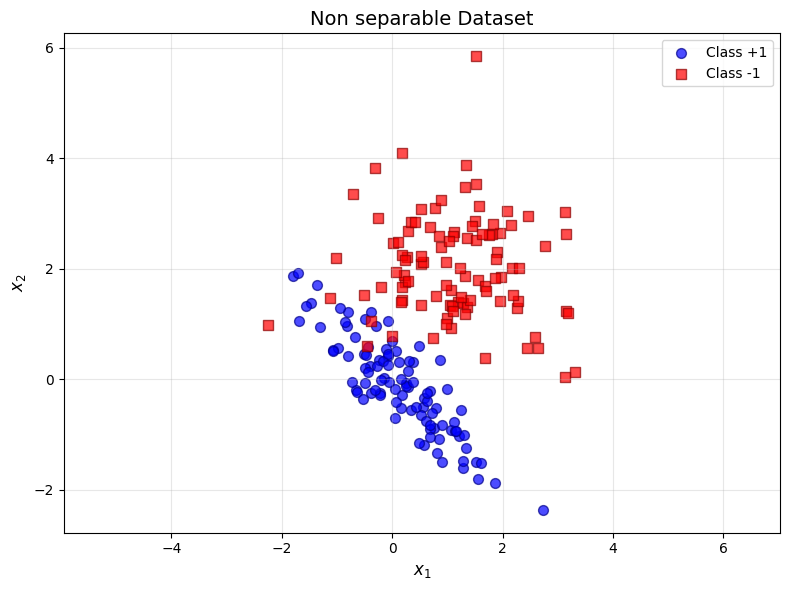

In [170]:
# Create the separable dataset
X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Separable dataset created with {len(y_sep)} samples")
print(f"Class +1: {np.sum(y_sep == 1)} samples")
print(f"Class -1: {np.sum(y_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_sep, y_sep, title="Separable Dataset")
plt.tight_layout()
plt.show()

# Create the non-separable dataset
X_non_sep, y_non_sep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
print(f"Non separable dataset created with {len(y_non_sep)} samples")
print(f"Class +1: {np.sum(y_non_sep == 1)} samples")
print(f"Class -1: {np.sum(y_non_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_non_sep, y_non_sep, title="Non separable Dataset")
plt.tight_layout()
plt.show()

## Experiments

w: [-0.18911393 -0.29661133]
b: 1.233280404617954


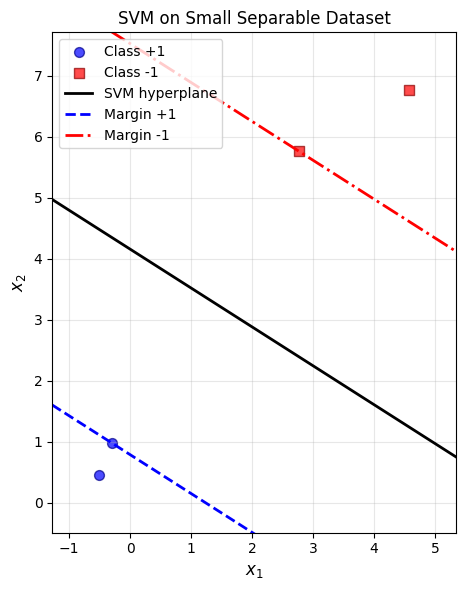

In [171]:
# Experiment 1. Separable dataset with 2 samples per class
X_small, y_small = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=2, seed=42)
w, b, _ = SVM_hyperplane(X_small, y_small, K=1.0)
print("w:", w)
print("b:", b)
plot_svm_with_margin(X_small, y_small, w, b, title="SVM on Small Separable Dataset")
plt.tight_layout()
plt.show()


K=0.1
w: [-0.23536804 -0.45913213]
b: 1.4139718625003859


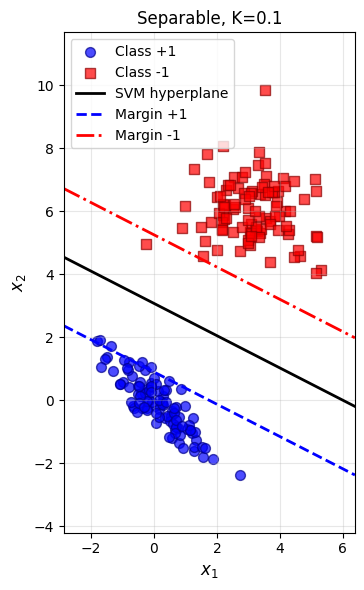

K=1
w: [-0.25645704 -0.53182677]
b: 1.5842891321274823


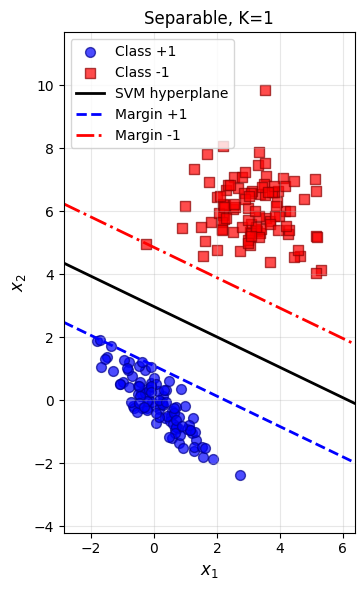

K=10
w: [-0.25601681 -0.53205559]
b: 1.5614494631661382


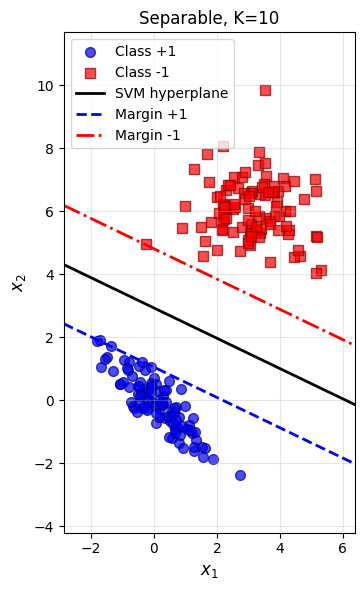

K=100
w: [-0.23986723 -0.60034395]
b: 2.172162099856027


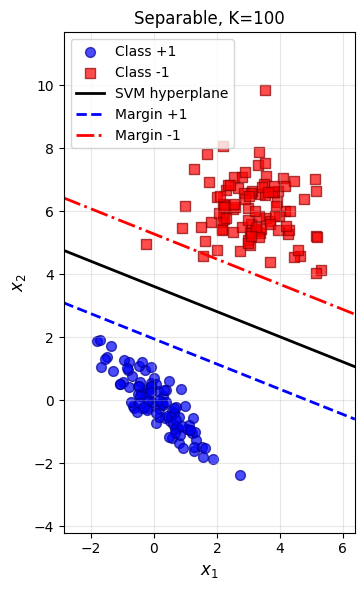

K=1000000.0
w: [nan nan]
b: nan


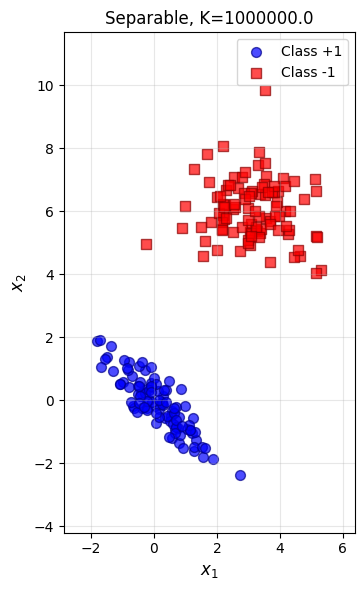

K=1000000000000.0
w: [nan nan]
b: nan


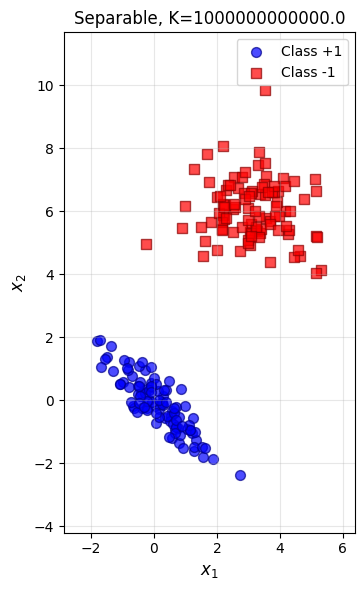

In [172]:
# Experiment 2. Separable dataset, 100 samples per class, multiple K values
K_values = [0.1, 1, 10, 100, 1e6, 1e12]
for K in K_values:
    X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
    w_sep, b_sep, _ = SVM_hyperplane(X_sep, y_sep, K=K)
    print(f"K={K}")
    print("w:", w_sep)
    print("b:", b_sep)
    plot_svm_with_margin(X_sep, y_sep, w_sep, b_sep, title=f"Separable, K={K}")
    plt.tight_layout()
    plt.show()


K=1
w: [-1.28731185 -1.76551683]
b: 1.6097735998425602


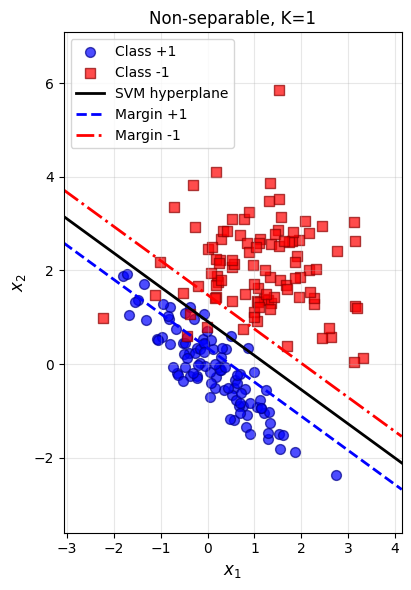

K=1000000.0
w: [-1.61325806 -2.43353944]
b: 2.1182120413265713


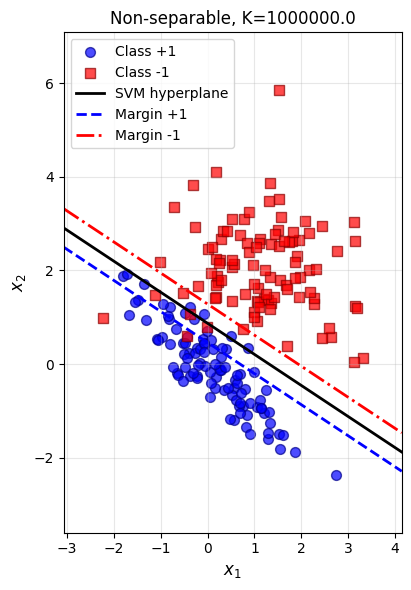

K=1000000000000.0
w: [-20597.8056489     704.73106232]
b: 2668.878043002846


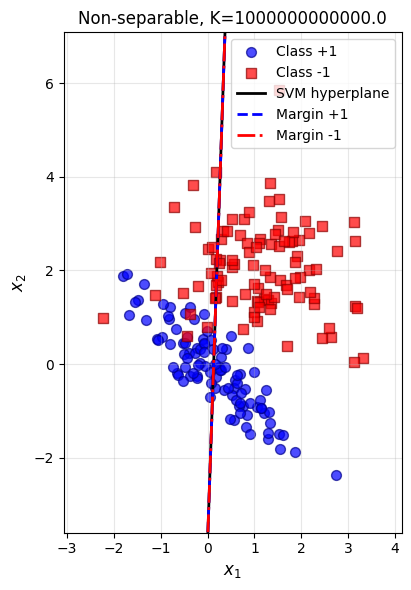

In [173]:
# Experiment 3: Non-separable dataset, 100 samples per class, multiple K values
K_values_nonsep = [1, 1e6, 1e12]
for K in K_values_nonsep:
    X_nonsep, y_nonsep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
    w_nonsep, b_nonsep, _ = SVM_hyperplane(X_nonsep, y_nonsep, K=K)
    print(f"K={K}")
    print("w:", w_nonsep)
    print("b:", b_nonsep)
    plot_svm_with_margin(X_nonsep, y_nonsep, w_nonsep, b_nonsep, title=f"Non-separable, K={K}")
    plt.tight_layout()
    plt.show()
